# Visualization gallery

Builds every figure used by the Streamlit dashboard (`dashboard/app.py`) from
the reusable functions in `src/visualizations.py`, and saves them to
`reports/figures/` so the dashboard and this notebook always show the same
plots. Run after `01_data_cleaning.ipynb` (needs `data/processed/cleaned_data.csv`).


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from scipy import stats

from src import statistics as rs
from src import visualizations as viz

df = rs.load_robust()
df.shape

(1500, 20)

## 1. Distributions with a fitted curve

Revenue, copies sold and price are heavily right-skewed, so each is fit and plotted on a log10 axis (see `src/statistics.py` for why mean/normal-based methods are a poor fit for this data).

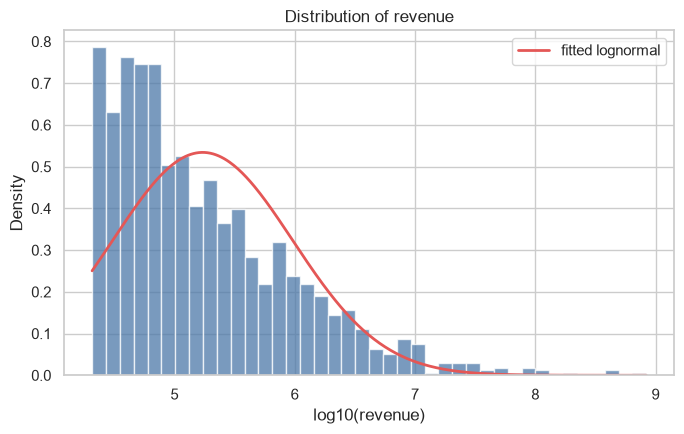

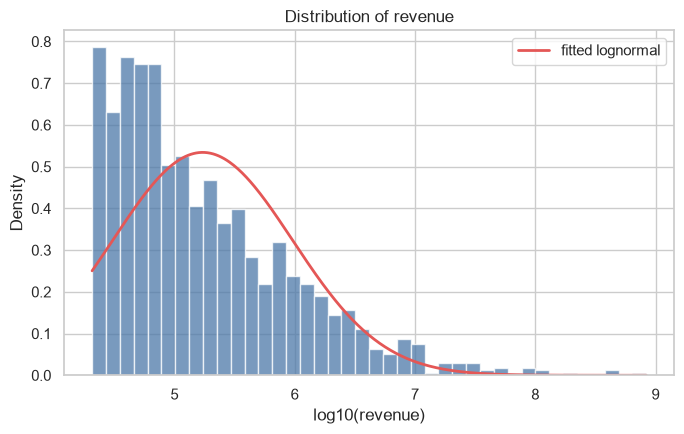

In [2]:
fig = viz.plot_histogram_with_distribution(df["revenue"], distribution="lognormal", log_scale=True, label="revenue")
rs.save_fig(fig, "viz_revenue_distribution.png")
fig

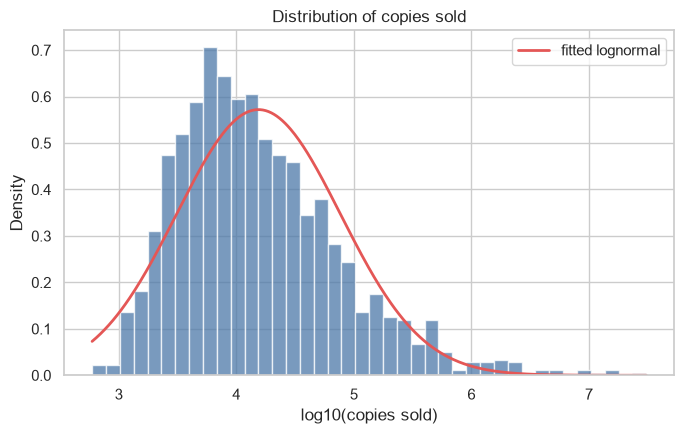

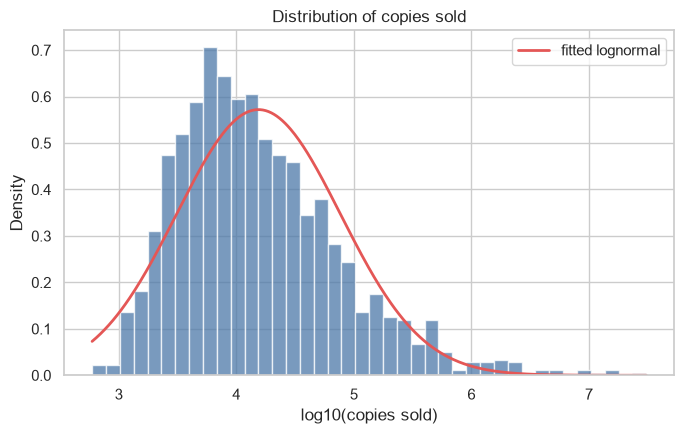

In [3]:
fig = viz.plot_histogram_with_distribution(df["copiesSold"], distribution="lognormal", log_scale=True, label="copies sold")
rs.save_fig(fig, "viz_copies_distribution.png")
fig

## 2. Correlation heatmap (Spearman)

Rank-based correlation among the numeric variables — the measure the analysis relies on, since Pearson on raw values is dominated by a handful of blockbusters.

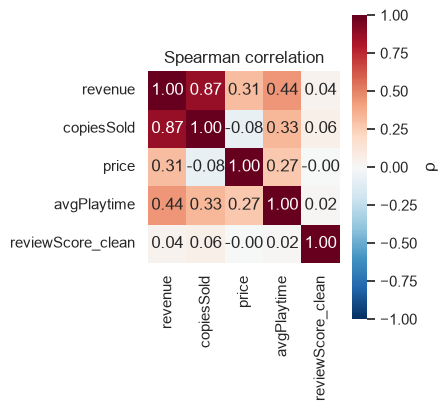

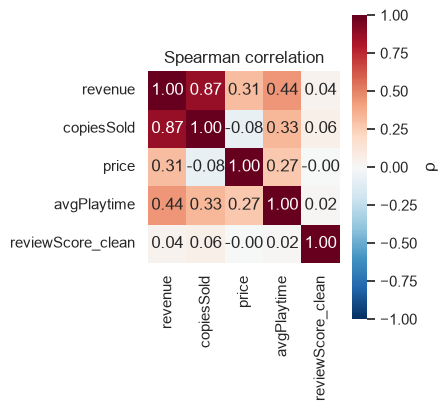

In [4]:
fig = viz.create_correlation_heatmap(
    df, columns=["revenue", "copiesSold", "price", "avgPlaytime", "reviewScore_clean"], method="spearman",
)
rs.save_fig(fig, "viz_correlation_heatmap.png")
fig

## 3. Boxplots by publisher class

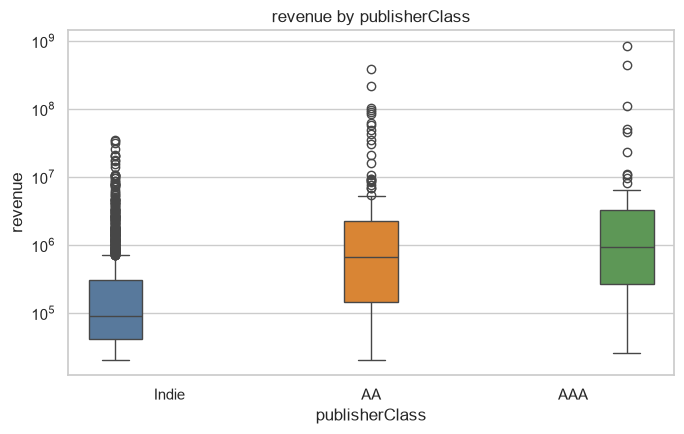

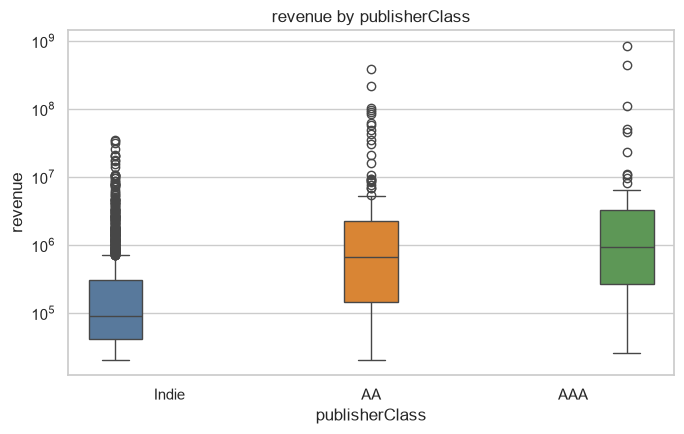

In [5]:
fig = viz.plot_boxplots_by_category(df, numeric_col="revenue", category_col="publisherClass", log_scale=True)
rs.save_fig(fig, "viz_boxplots_revenue_by_class.png")
fig

## 4. Q-Q plot against the fitted model

Checks the lognormal fit for revenue directly (compare to the truncated-likelihood fits in `05_distribution_fitting.ipynb`, which also account for the left-truncation from taking only the top 1,500 games).

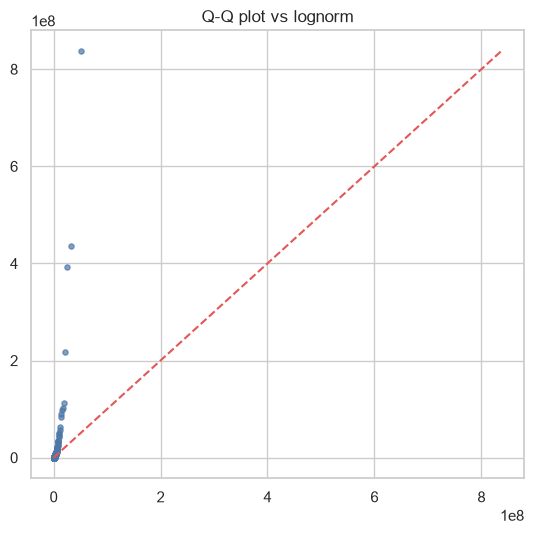

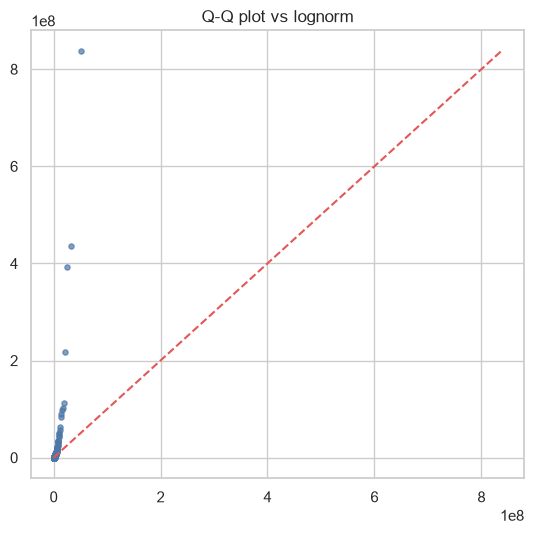

In [6]:
params = stats.lognorm.fit(df["revenue"], floc=0)
fig = viz.plot_qq_comparison(df["revenue"], distribution="lognorm", dist_params=params)
rs.save_fig(fig, "viz_qq_revenue_lognormal.png")
fig

## 5. Interactive scatter (Plotly)

The same figure the dashboard's price/review pages render — kept interactive here so it can be inspected directly in the notebook.

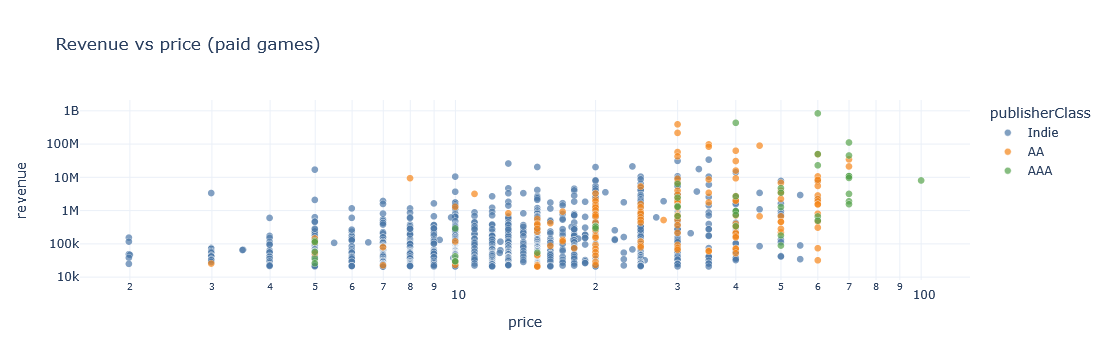

In [7]:
fig = viz.create_interactive_scatter(
    df[df["price"] > 0], x_col="price", y_col="revenue", color_col="publisherClass",
    log_x=True, log_y=True, title="Revenue vs price (paid games)",
)
fig.write_html(str(rs.FIG_DIR / "viz_scatter_price_revenue.html"))
fig.show()

## 6. Shared dashboard layout

`dashboard_layout()` is the single source of truth for page config, class colors/order, and accent colors — `dashboard/app.py` reads it instead of redeclaring these constants.

In [8]:
viz.dashboard_layout()

{'page_config': {'page_title': 'Steam 2024 Revenue',
  'page_icon': '🎮',
  'layout': 'wide'},
 'class_order': ['Indie', 'AA', 'AAA'],
 'class_colors': {'Indie': '#4C78A8', 'AA': '#F58518', 'AAA': '#54A24B'},
 'plotly_template': 'plotly_white',
 'accent_colors': {'blue': '#4C78A8', 'grey': '#9D9D9D', 'red': '#E45756'}}